# Machine Learning Model Comparison

## Objective

The objective of this project is to train and evaluate multiple machine learning
classification models and determine which model performs better using suitable
evaluation metrics.

Two machine learning models are compared:

1. Logistic Regression
2. Random Forest Classifier

The models are evaluated using accuracy, precision, recall, F1-score,
confusion matrix, and ROC-AUC.

## 1. Importing Required Libraries

The required Python libraries are imported for data handling, visualization,
machine learning model development, preprocessing, and performance evaluation.

The main libraries used are NumPy, Pandas, Matplotlib, Seaborn, and Scikit-learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## 2. Dataset Loading

The Breast Cancer Wisconsin dataset available through Scikit-learn is used
for this classification task.

The dataset contains numerical features describing characteristics of cell
nuclei. The target variable represents two classes.

The dataset contains 569 samples and 30 input features.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569


## 3. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure,
features, target distribution, and statistical characteristics of the dataset.

The first few records are inspected to understand the feature values.

In [3]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Dataset Information

The dataset information is examined to verify the number of observations,
features, data types, and non-null values.

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Target Class Distribution

The target class distribution is checked to understand how many samples
belong to each class.

This is important because a highly imbalanced dataset can affect the
interpretation of classification metrics.

In [5]:
y.value_counts()

target
1    357
0    212
Name: count, dtype: int64

### Statistical Summary

Descriptive statistics are calculated to understand the central tendency,
spread, and range of the numerical features.

In [6]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


## 4. Data Quality Check

Before training the machine learning models, the dataset is checked for
missing values and duplicate observations.

This step helps ensure that the models are trained using clean and
consistent data.

In [7]:
print("Missing values:")
print(X.isnull().sum().sum())

Missing values:
0


In [8]:
print("Duplicate rows:", X.duplicated().sum())

Duplicate rows: 0


### Target Distribution Visualization

The target classes are visualized using a bar chart to provide a clear
view of the number of samples in each class.

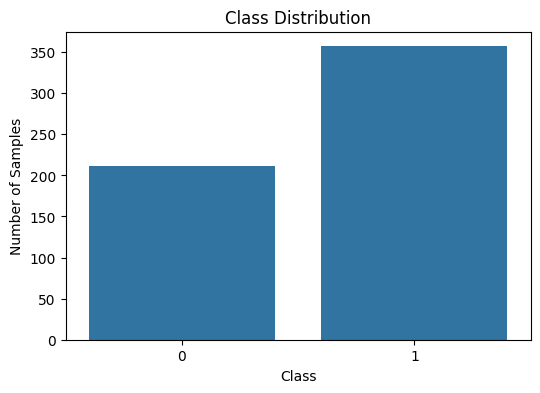

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(x=y)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

plt.show()

## 5. Train-Test Split

The dataset is divided into training and testing subsets.

80% of the data is used for training the models, while the remaining 20%
is reserved for testing.

A fixed random state is used to make the experiment reproducible.
Stratified splitting is used to preserve the class distribution in both
the training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


## 6. Model 1 – Logistic Regression

Logistic Regression is used as the first classification model and serves
as a baseline model for comparison.

Feature scaling is applied using StandardScaler because Logistic Regression
can be affected by differences in feature scales.

A Pipeline is used to combine preprocessing and model training in a
consistent manner.

In [11]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

### Logistic Regression Evaluation

The Logistic Regression model is evaluated using accuracy, precision,
recall, F1-score, and ROC-AUC.

These metrics provide a broader evaluation than accuracy alone.

In [12]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Logistic Regression
-------------------
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1 Score : 0.9861111111111112
ROC-AUC  : 0.9953703703703703


## 7. Model 2 – Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple
decision trees to perform classification.

It is selected as the second model because it can capture nonlinear
relationships and interactions between features and provides a useful
comparison with Logistic Regression.

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

### Random Forest Evaluation

The Random Forest model is evaluated using the same metrics as Logistic
Regression so that both models can be compared fairly.

The evaluation metrics include accuracy, precision, recall, F1-score,
and ROC-AUC.

In [14]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest
-------------
Accuracy : 0.956140350877193
Precision: 0.958904109589041
Recall   : 0.9722222222222222
F1 Score : 0.9655172413793104
ROC-AUC  : 0.9930555555555556


## 8. Model Performance Comparison

Both models are now compared using the same evaluation metrics.

Using multiple metrics provides a more reliable assessment of model
performance than relying on accuracy alone.

In [15]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993056


## 9. Confusion Matrix Analysis

A confusion matrix is used to examine the classification results in more
detail.

It shows the number of correctly and incorrectly classified samples for
each class.

This helps identify false positives and false negatives that may not be
obvious from accuracy alone.

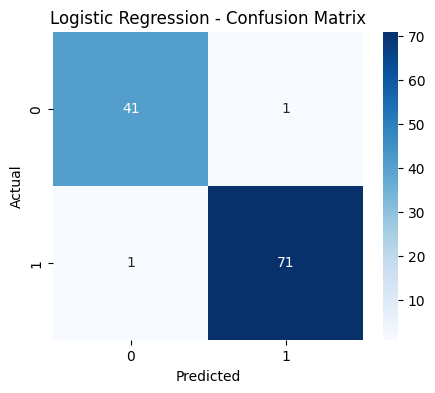

In [16]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

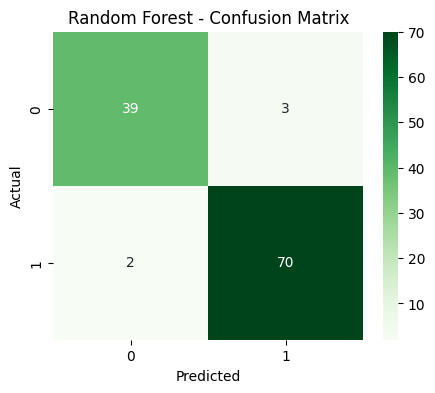

In [17]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Detailed Classification Reports

Classification reports provide class-wise precision, recall, F1-score,
and support values.

These results provide additional detail about how each model performs
for the individual target classes.

In [18]:
print("Logistic Regression Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [19]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 10. Performance Visualization

The performance of both machine learning models is visualized using a
comparison chart.

The graph provides an intuitive representation of the differences between
the models across the selected evaluation metrics.

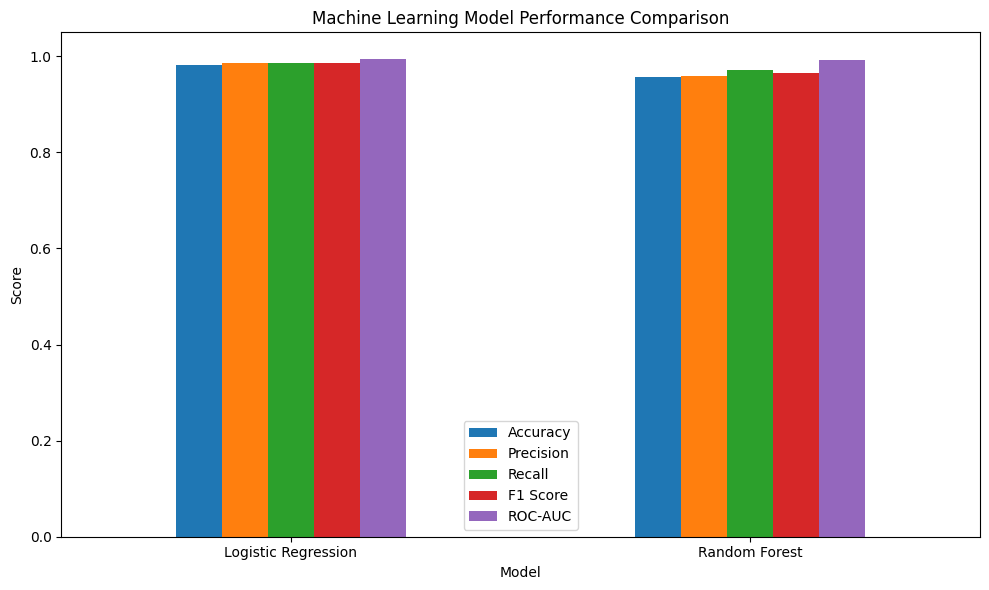

In [21]:
results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.legend()
plt.tight_layout()
plt.show()

### Comparison of Results

The experimental results show that Logistic Regression achieved better
overall performance than Random Forest on the selected test set.

Logistic Regression achieved an accuracy of approximately 98.25% and a
ROC-AUC score of approximately 99.54%.

Random Forest achieved an accuracy of approximately 95.61% and a
ROC-AUC score of approximately 99.31%.

Logistic Regression also achieved higher precision, recall, and F1-score
in this experiment.

In [22]:
results.to_csv("model_comparison.csv", index=False)

# 11. Conclusion

Two machine learning classification models, Logistic Regression and
Random Forest, were trained and evaluated using the Breast Cancer
Wisconsin dataset.

The models were compared using accuracy, precision, recall, F1-score,
ROC-AUC, and confusion matrices.

Based on the experimental results, Logistic Regression performed better
than Random Forest on the selected test set.

Logistic Regression achieved 98.25% accuracy, 98.61% precision,
98.61% recall, 98.61% F1-score, and a ROC-AUC of 99.54%.

Random Forest achieved 95.61% accuracy, 95.89% precision, 97.22% recall,
96.55% F1-score, and a ROC-AUC of 99.31%.

Therefore, Logistic Regression was selected as the better-performing
model for this particular experiment.

The result also demonstrates that a simpler model can outperform a more
complex ensemble model when the characteristics of the dataset are well
suited to the simpler decision boundary.

However, this conclusion is specific to the dataset, preprocessing
pipeline, train-test split, and model configurations used in this
experiment.